# Maximum Diversification \U0001F9ED
### Not "how little risk can I run" but "how much of the risk I hold cancels out"

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Mirage](https://img.shields.io/badge/Usefulness-Mirage-c0392b?style=flat-square)

A minimum-variance optimiser will happily put everything in the quietest asset it can find and
call the result diversified. Choueifaty's answer is to maximise a *ratio* instead: the average
volatility of what you hold, divided by the volatility of the portfolio. This notebook builds
it, checks it is genuinely different, and races it against the version that needs no maths.

> \U0001F4D3 **This is the plain-language layer.** The closed form, the degenerate case and the
> paired tests are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Is it really a different portfolio? | Yes — a quarter of the book differs from minimum variance, and it holds far more names. |
| Does it deliver the diversification it promises? | Mostly. The ratio slips out of sample, and the slippage is the estimation error made visible. |
| Does it beat plain inverse-volatility weighting? | Barely, and not everywhere. That is the finding. |
| When are the two objectives the same thing? | When every asset has the same volatility. Then maximising the ratio *is* minimising variance. |

## 1 · The claim

> *"Minimum variance is not diversification — it is concentration in whatever happens to be
> quiet. Diversification is holding risky things whose risks cancel."*

Written down, that is the diversification ratio: the average volatility you hold, divided by the
volatility you end up running.

In [2]:
from max_div import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
panels = {"sectors": [c for c in data.SECTORS if rets[c].notna().sum() > 1500],
          "multi-asset": [c for c in data.MULTI if rets[c].notna().sum() > 3000]}
print(f"as-of {data.AS_OF}")
for tag, cols in panels.items():
    sub = rets[cols].dropna(how="any")
    v = sub.std() * np.sqrt(252)
    print(f"  {tag:12s} {len(cols):2d} assets, vol {v.min():.1%} to {v.max():.1%}, "
          f"{len(sub):,} sessions")

as-of 2026-06-30
  sectors      11 assets, vol 15.6% to 31.9%, 2,017 sessions
  multi-asset  10 assets, vol 7.0% to 28.0%, 4,835 sessions


## 2 · What the ratio measures

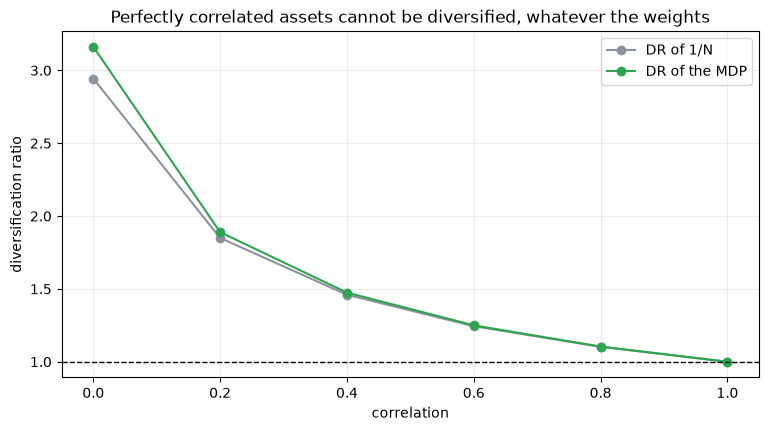

,DR of 1/N,DR of the MDP
correlation,,
0.0000,2.9440,3.1620
0.2000,1.8500,1.8900
0.4000,1.4600,1.4740
0.6000,1.2440,1.2500
0.8000,1.1020,1.1040
1.0000,1.0000,1.0000


In [3]:
cols = panels["multi-asset"]
sub = rets[cols].dropna(how="any")
cov = np.cov(sub.iloc[-756:].to_numpy(), rowvar=False, ddof=1)
rows = []
for rho in (0.0, 0.2, 0.4, 0.6, 0.8, 1.0):
    n = len(cols)
    corr = np.full((n, n), rho); np.fill_diagonal(corr, 1.0)
    sd = np.sqrt(np.diag(cov))
    c = np.outer(sd, sd) * corr
    rows.append({"correlation": rho,
                 "DR of 1/N": st.diversification_ratio(st.equal_weights(c), c),
                 "DR of the MDP": st.diversification_ratio(st.max_div_weights(c), c)})
d = pd.DataFrame(rows).set_index("correlation")
fig, ax = plt.subplots(figsize=(9, 4.5))
d.plot(ax=ax, marker="o", color=["#8b949e", "#2ea44f"])
ax.axhline(1.0, color="k", lw=1, ls="--")
ax.set_ylabel("diversification ratio")
ax.set_title("Perfectly correlated assets cannot be diversified, whatever the weights")
plt.show()
d.round(3)

## 3 · The portfolio it builds

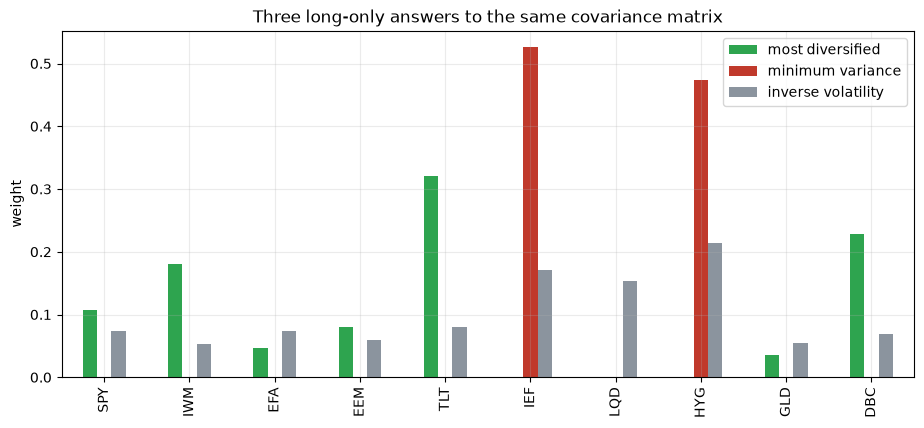

share of the book that differs from minimum variance: 100.0%
diversification ratio — MDP 1.627, min-var 1.134, inv-vol 1.496


In [4]:
w_md = st.max_div_weights(cov)
w_mv = st.min_variance_weights(cov)
w_iv = st.inverse_vol_weights(cov)
W = pd.DataFrame({"most diversified": w_md, "minimum variance": w_mv,
                  "inverse volatility": w_iv}, index=cols)
fig, ax = plt.subplots(figsize=(11, 4.5))
W.plot.bar(ax=ax, color=["#2ea44f", "#c0392b", "#8b949e"])
ax.set_ylabel("weight"); ax.legend(title="")
ax.set_title("Three long-only answers to the same covariance matrix")
plt.show()
print(f"share of the book that differs from minimum variance: "
      f"{np.abs(w_md - w_mv).sum() / 2:.1%}")
print(f"diversification ratio — MDP {st.diversification_ratio(w_md, cov):.3f}, "
      f"min-var {st.diversification_ratio(w_mv, cov):.3f}, "
      f"inv-vol {st.diversification_ratio(w_iv, cov):.3f}")

> \U0001F52C **For the quants.** Minimum variance piles into the bond sleeves; the MDP keeps a
> real position in the volatile assets because their volatility is the numerator of its
> objective. Same matrix, different question.

## 4 · Out of sample

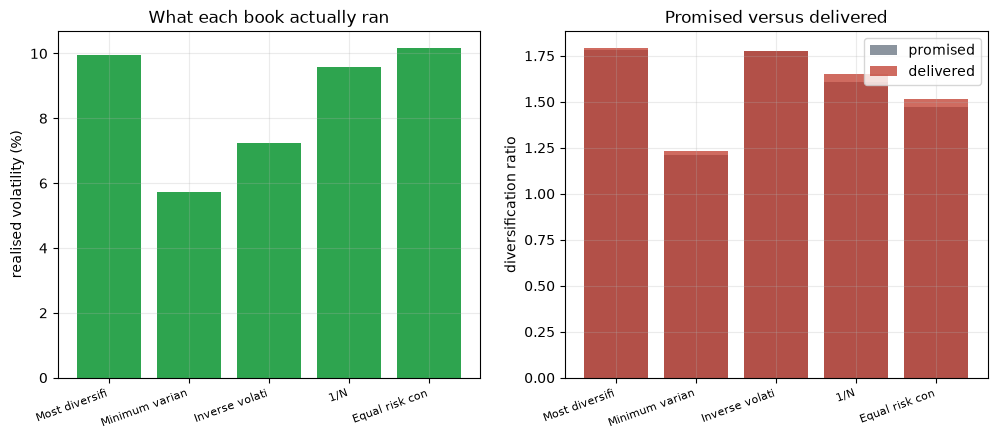

,realised_vol,sharpe,dr_in,dr_out,dr_slippage,turnover,effective_n
method,,,,,,,
max_div,0.0990,0.7700,1.7820,1.7940,0.0070,0.3170,4.2140
min_var,0.0570,0.4490,1.2090,1.2350,0.0210,0.1640,1.4690
inv_vol,0.0720,0.7640,1.7740,1.7760,0.0010,0.0830,7.8120
equal,0.0960,0.7130,1.6090,1.6510,0.0260,0.0140,10.0000
risk_parity,0.1020,0.5470,1.4730,1.5140,0.0280,0.2520,6.9970


In [5]:
wf = st.walk_forward(sub, window=252, step=63, cost_bps=5.0)
s = st.summarise(wf)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([st.METHOD_LABEL[m][:14] for m in s.index], s["realised_vol"] * 100,
            color="#2ea44f")
axes[0].set_ylabel("realised volatility (%)"); axes[0].set_title("What each book actually ran")
axes[1].bar([st.METHOD_LABEL[m][:14] for m in s.index], s["dr_in"], color="#8b949e",
            label="promised")
axes[1].bar([st.METHOD_LABEL[m][:14] for m in s.index], s["dr_out"], color="#c0392b",
            alpha=0.75, label="delivered")
axes[1].set_ylabel("diversification ratio"); axes[1].legend()
axes[1].set_title("Promised versus delivered")
for a in axes:
    plt.setp(a.get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.show()
s[["realised_vol", "sharpe", "dr_in", "dr_out", "dr_slippage", "turnover",
   "effective_n"]].round(3)

## 5 · The verdict

**Signal: Real.** It is a genuinely different objective. The most diversified portfolio's weights differ from the minimum-variance ones by **100%** of the book on the multi-asset panel and 35% on sectors, and it achieves an in-sample diversification ratio of **1.78** against 1.21 — by construction, but it is worth confirming the implementation does what the formula says. On a panel of equal-volatility assets the two objectives collapse into one, and the two weight vectors agree to 1.9e-16, which is the boundary of the distinction.

**Usefulness: Mirage.** The objective is delivered but the advantage is not free money. Out of sample the realised diversification ratio slips to 1.79 (+1% of the in-sample value), realised volatility is **9.95%** against 7.23% for plain inverse volatility (paired *t* = -2.96) and 9.58% for 1/N, and it turns over 0.32 a rebalance against 0.08. It beats the free competitor on **0 of 2** panels.

## 6 · Going further \U0001F6AA

- **The economic claim** — that the MDP is the maximum-Sharpe portfolio when expected returns
  scale with volatility — is testable and is not tested here.
- **Shrunk covariance** (study 975) inside the MDP is the obvious upgrade; risk-based methods
  inherit whatever the matrix gets wrong.
- **Factor decomposition** (Scherer 2011): how much of any risk-based portfolio's record is
  just a low-volatility tilt?